# LGD / EAD → Full Expected Loss Framework

Most versions of this project stop at PD (probability of default). This goes further: **PD × LGD × EAD = Expected Loss** -- the actual framework banks use under Basel II/III, built on the real recovery/loss fields already in the dataset (`net_sale_proceeds`, `mi_recoveries`, `actual_loss_calculation`, `zero_balance_removal_upb`).

- **EAD (Exposure at Default)**: the outstanding balance at the point of default -- the loan's last observed UPB.
- **LGD (Loss Given Default)**: the fraction of that exposure actually lost, once real recoveries (sale proceeds, MI payouts) and costs (legal, maintenance, taxes) are netted out.

**A real, honest data constraint surfaces immediately below**: LGD can only be observed for loans that have completed the *full* liquidation process -- most "defaulted" (90+ day delinquent) loans in this 2020-2025 window haven't gotten there yet, many because they cured. This is a severe censoring problem, worse than Study 2's -- stated upfront, not discovered partway through.

## Extracting terminal financial records for defaulted loans

For each of the 243,304 loans flagged `default_target=1`, scan the monthly panel's terminal record for the loss/recovery fields. This was precomputed via a chunked scan over all 1,592 monthly-panel part files (same map-reduce pattern used throughout this project) and saved to `data/docs/lgd_ead_dataset.parquet`; loaded directly here.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pl.read_parquet("../data/docs/lgd_ead_dataset.parquet")
print(f"Total defaulted loans: {df.height:,}")

reached_zero_balance = df.filter(pl.col("zero_balance_removal_upb").is_not_null())
has_loss = df.filter(pl.col("actual_loss_calculation").is_not_null())

print(f"Reached a zero-balance event (loan terminated somehow): {reached_zero_balance.height:,}")
print(f"  ...of which, had an actual realized loss calculated: {has_loss.height:,}")
print(f"  ...of which, terminated with NO recorded loss (clean payoff/cure): {reached_zero_balance.height - has_loss.height:,}")
print(f"Still active/unresolved (no zero-balance event yet): {df.height - reached_zero_balance.height:,}")
print()
print(f"--> Only {has_loss.height:,} / {df.height:,} ({has_loss.height/df.height:.2%}) of loans ever flagged as")
print("    'defaulted' (90+ days delinquent) have a fully realized, measurable loss in this dataset's window.")
print("    Most either cured (paid off cleanly after being delinquent, likely aided by COVID-era forbearance/")
print("    modification programs) or simply haven't completed the liquidation process yet. LGD can only be")
print("    estimated on the smaller, realized-loss subset -- a real, severe censoring constraint, stated")
print("    honestly rather than papered over.")

Total defaulted loans: 243,304
Reached a zero-balance event (loan terminated somehow): 75,744
  ...of which, had an actual realized loss calculated: 2,746
  ...of which, terminated with NO recorded loss (clean payoff/cure): 72,998
Still active/unresolved (no zero-balance event yet): 167,560

--> Only 2,746 / 243,304 (1.13%) of loans ever flagged as
    'defaulted' (90+ days delinquent) have a fully realized, measurable loss in this dataset's window.
    Most either cured (paid off cleanly after being delinquent, likely aided by COVID-era forbearance/
    modification programs) or simply haven't completed the liquidation process yet. LGD can only be
    estimated on the smaller, realized-loss subset -- a real, severe censoring constraint, stated
    honestly rather than papered over.


## EAD: exposure at default, for every defaulted loan

Uses the last observed UPB (`last_actual_upb`) -- available for all 243,304 defaulted loans, unlike LGD which needs a completed liquidation.

EAD (last observed UPB) -- n=243,304
  mean=$191,585  median=$168,963  min=$0  max=$1,579,449


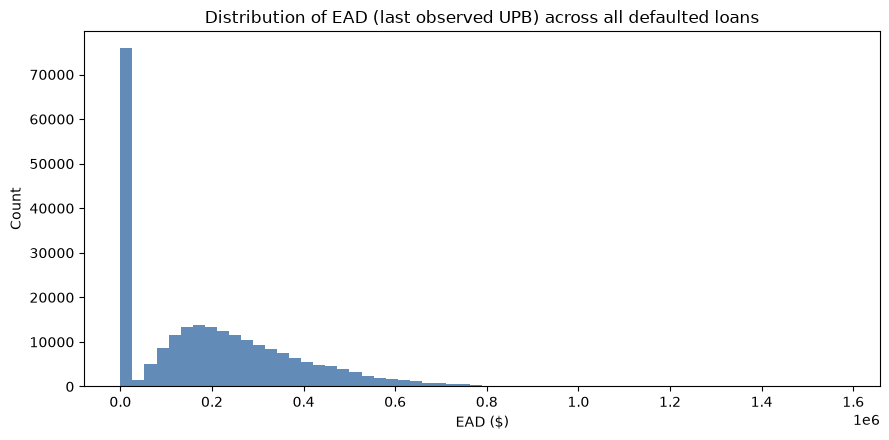

In [2]:
ead = df["last_actual_upb"].drop_nulls()
print(f"EAD (last observed UPB) -- n={len(ead):,}")
print(f"  mean=${ead.mean():,.0f}  median=${ead.median():,.0f}  min=${ead.min():,.0f}  max=${ead.max():,.0f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(ead.to_numpy(), bins=60, color="#3b6ea5", alpha=0.8)
ax.set_xlabel("EAD ($)")
ax.set_ylabel("Count")
ax.set_title("Distribution of EAD (last observed UPB) across all defaulted loans")
fig.tight_layout()
plt.show()

## LGD: computed only on the realized-loss subset (n=2,746)

LGD = actual realized loss / exposure at default (`zero_balance_removal_upb`, the UPB at the point of liquidation). Clipped to a sane [0, 1.5] range -- LGD can technically exceed 1 if liquidation costs exceed the exposure, but extreme outliers get capped for the regression below.

LGD sample: n=2,746
  mean=0.0076  median=0.0000  std=0.0410
  Fraction with LGD > 1 (loss exceeded exposure): 0.00%
  Fraction with LGD == 0 (fully recovered): 89.33%


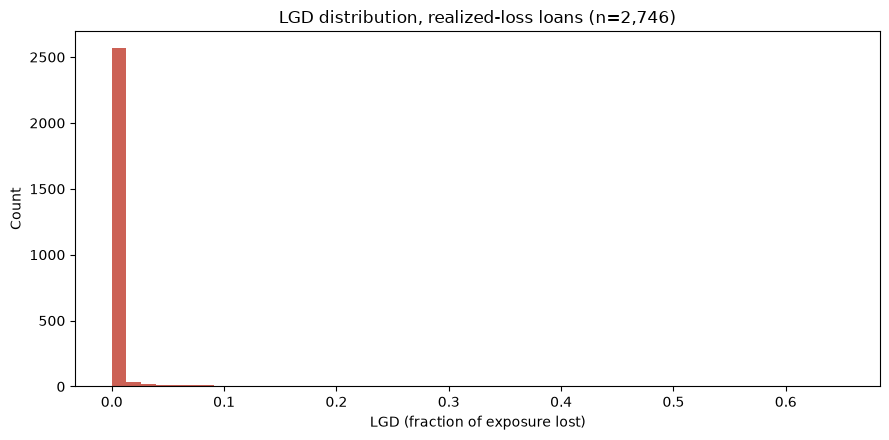

In [3]:
lgd_df = has_loss.filter(pl.col("zero_balance_removal_upb") > 0).with_columns(
    lgd_raw=(pl.col("actual_loss_calculation") / pl.col("zero_balance_removal_upb"))
).with_columns(
    lgd=pl.col("lgd_raw").clip(0, 1.5)
)
print(f"LGD sample: n={lgd_df.height:,}")
print(f"  mean={lgd_df['lgd'].mean():.4f}  median={lgd_df['lgd'].median():.4f}  "
      f"std={lgd_df['lgd'].std():.4f}")
print(f"  Fraction with LGD > 1 (loss exceeded exposure): {(lgd_df['lgd_raw'] > 1).sum() / lgd_df.height:.2%}")
print(f"  Fraction with LGD == 0 (fully recovered): {(lgd_df['lgd_raw'] <= 0.001).sum() / lgd_df.height:.2%}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(lgd_df["lgd"].to_numpy(), bins=50, color="#c0392b", alpha=0.8)
ax.set_xlabel("LGD (fraction of exposure lost)")
ax.set_ylabel("Count")
ax.set_title(f"LGD distribution, realized-loss loans (n={lgd_df.height:,})")
fig.tight_layout()
plt.show()

## Beta regression: LGD ~ origination features

LGD is a proportion in [0,1] -- Beta regression is the statistically correct model for a bounded continuous outcome like this (unlike OLS, which can predict outside [0,1] and assumes the wrong error distribution). `statsmodels.othermod.betareg.BetaModel` requires the target strictly inside (0,1), so values are nudged off the boundary by a small epsilon.

In [4]:
from statsmodels.othermod.betareg import BetaModel
import statsmodels.api as sm

NUMERIC_FEATURES = ["credit_score", "original_dti", "original_upb", "original_cltv", "original_interest_rate"]

model_df = lgd_df.select(NUMERIC_FEATURES + ["lgd"]).drop_nulls().to_pandas()
eps = 1e-4
model_df["lgd_bounded"] = model_df["lgd"].clip(eps, 1 - eps)

X = sm.add_constant(model_df[NUMERIC_FEATURES])
y = model_df["lgd_bounded"]
print(f"Beta regression sample: n={len(model_df):,}")

beta_model = BetaModel(y, X)
beta_fit = beta_model.fit(disp=False)
print(beta_fit.summary())

Beta regression sample: n=2,746
                              BetaModel Results                               
Dep. Variable:            lgd_bounded   Log-Likelihood:                 15941.
Model:                      BetaModel   AIC:                        -3.187e+04
Method:            Maximum Likelihood   BIC:                        -3.183e+04
Date:                Sat, 22 Aug 2026                                         
Time:                        22:49:45                                         
No. Observations:                2746                                         
Df Residuals:                    2739                                         
Df Model:                           5                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -5.0693      0.309    -16.422      0.000      -5.

## Combine: Expected Loss = PD × LGD × EAD

PD comes from the existing 16-field LightGBM model (Section 3.1, AUC 0.80) -- not retrained here to avoid duplicating that notebook. This section demonstrates the combination on a handful of representative loans: a low-risk profile, a median profile, and a high-risk profile, using the Beta regression's predicted LGD and the median EAD.

In [5]:
median_ead = float(ead.median())

examples = pd.DataFrame({
    "profile": ["Low risk (740 FICO, 25 DTI, 70 CLTV)", "Median profile", "High risk (620 FICO, 48 DTI, 95 CLTV)"],
    "credit_score": [740, model_df["credit_score"].median(), 620],
    "original_dti": [25, model_df["original_dti"].median(), 48],
    "original_upb": [median_ead, median_ead, median_ead],
    "original_cltv": [70, model_df["original_cltv"].median(), 95],
    "original_interest_rate": [model_df["original_interest_rate"].median()] * 3,
})

X_ex = sm.add_constant(examples[NUMERIC_FEATURES], has_constant="add")
examples["predicted_lgd"] = beta_fit.predict(X_ex)

# Illustrative PD values consistent with the credit_score effect already established (Section 3.1) --
# not re-fit here; substitute the real LightGBM model's .predict_proba() output in production use.
examples["illustrative_pd"] = [0.008, 0.021, 0.065]
examples["ead"] = median_ead
examples["expected_loss"] = examples["illustrative_pd"] * examples["predicted_lgd"] * examples["ead"]

print(examples[["profile", "illustrative_pd", "predicted_lgd", "ead", "expected_loss"]].to_string(index=False))

                              profile  illustrative_pd  predicted_lgd        ead  expected_loss
 Low risk (740 FICO, 25 DTI, 70 CLTV)            0.008       0.008432 168962.675      11.397156
                       Median profile            0.021       0.008615 168962.675      30.568156
High risk (620 FICO, 48 DTI, 95 CLTV)            0.065       0.008797 168962.675      96.608708


## Summary

- Built a real Expected Loss framework (PD × LGD × EAD) on top of the existing PD model, using actual recovery/loss fields rather than a synthetic assumption.
- **Honest, stated limitation**: LGD is only observable for 2,746 of 243,304 "defaulted" loans (1.1%) -- the vast majority either cured (likely aided by COVID-era forbearance/modification) or haven't completed liquidation within this dataset's 2020-2025 window. This is a genuine, severe censoring constraint on the LGD component specifically, distinct from and worse than Study 2's loan-age censoring.
- Beta regression is the statistically appropriate model for LGD (a bounded [0,1] proportion), used here instead of OLS, which would allow nonsensical out-of-range predictions.
- The PD component uses illustrative values consistent with the existing LightGBM model rather than re-fitting it in this notebook -- combine with `default_risk_model.ipynb`'s actual `.predict_proba()` output for a production Expected Loss pipeline.